# Previsão de Preços de Criptomoedas com LSTM e MiroFish

Pipeline completo para previsão de preços do Ethereum usando dados históricos da API CoinGecko.


In [1]:
import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent

if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

from src.data_loader import get_historical_data
from src.preprocessing import (
    resample_data,
    create_sequences,
    split_series_before_scaling,
    scale_train_val_test,
)
from src.model_lstm import build_lstm_model
from src.train import train_model
from src.evaluate import evaluate_model
from src.predict import predict_future

from src.models_mirofish.mirofish_model import MiroFishModel
from src.models_mirofish.train_mirofish import train_mirofish_model
from src.models_mirofish.evaluate_mirofish import evaluate_mirofish_model

import matplotlib.pyplot as plt


## 1. Coleta dos dados


In [2]:
coin = "ethereum"
days = 120
window_size = 24

df = get_historical_data(coin=coin, days=days)
df.head()


,price
timestamp,
2026-01-01,2966.774180
2026-01-02,3000.419117
2026-01-03,3121.900672
2026-01-04,3126.041091
2026-01-05,3139.057042


## 2. Visualização inicial da série


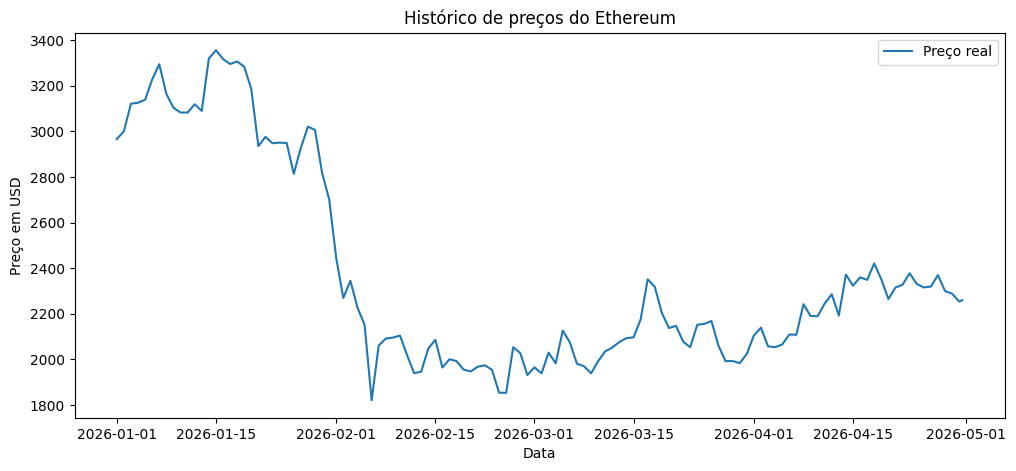

In [3]:
plt.figure(figsize=(12, 5))
plt.plot(df.index, df["price"], label="Preço real")
plt.title("Histórico de preços do Ethereum")
plt.xlabel("Data")
plt.ylabel("Preço em USD")
plt.legend()
plt.show()


## 3. Pré-processamento


In [4]:
import numpy as np

df_resampled = resample_data(df, freq="1h")

train_df, val_df, test_df = split_series_before_scaling(
    df_resampled,
    train_ratio=0.7,
    val_ratio=0.15,
)

train_scaled, val_scaled, test_scaled, scaler = scale_train_val_test(
    train_df.values,
    val_df.values,
    test_df.values,
)

full_scaled = np.concatenate(
    [train_scaled, val_scaled, test_scaled],
    axis=0,
)

X_all, y_all = create_sequences(full_scaled, window_size=window_size)

total = len(X_all)
train_end = int(total * 0.7)
val_end = int(total * 0.85)

X_train, y_train = X_all[:train_end], y_all[:train_end]
X_val, y_val = X_all[train_end:val_end], y_all[train_end:val_end]
X_test, y_test = X_all[val_end:], y_all[val_end:]

print("X_train:", X_train.shape)
print("X_val:", X_val.shape)
print("X_test:", X_test.shape)


X_train: (1990, 24, 1)
X_val: (426, 24, 1)
X_test: (427, 24, 1)


## 4. Modelo LSTM


In [5]:
lstm_model = build_lstm_model((X_train.shape[1], X_train.shape[2]))
lstm_model.summary()


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 24, 64)         │        16,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 24, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 64)             │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 49,985 (195.25 KB)

 Trainable params: 49,985 (195.25 KB)

 Non-trainable params: 0 (0.00 B)

## 5. Treinamento da LSTM


Epoch 1/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 4s 18ms/step - loss: 0.0221 - val_loss: 1.9807e-04
Epoch 2/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 0.0026 - val_loss: 1.5751e-04
Epoch 3/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 0.0023 - val_loss: 1.3485e-04
Epoch 4/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 0.0021 - val_loss: 1.3335e-04
Epoch 5/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - loss: 0.0019 - val_loss: 1.7738e-04
Epoch 6/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - loss: 0.0019 - val_loss: 2.8620e-04
Epoch 7/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - loss: 0.0018 - val_loss: 1.1631e-04
Epoch 8/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - loss: 0.0018 - val_loss: 2.4297e-04
Epoch 9/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - loss: 0.0019 - val_loss: 1.2724e-04
Epoch 10/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - loss: 0.0017 - val_loss: 1.6431e-04
Epoch 11/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - loss: 0.0015 - val_loss: 1.0542e-04
Epoch 12/20
63/63 ━

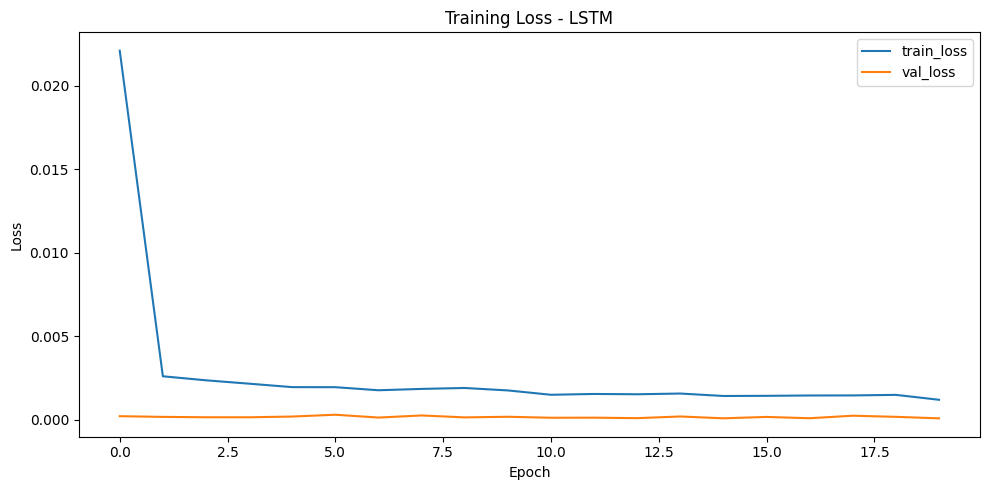

LSTM salvo em: /Users/karenota/Desktop/Previs-o-de-Criptomoedas---LSTMs/outputs/models/lstm_model.keras


In [6]:
lstm_model, history, lstm_model_path = train_model(
    lstm_model,
    X_train,
    y_train,
    X_val,
    y_val,
    epochs=20,
    batch_size=32,
    patience=8,
    model_name="lstm_model.keras",
)

print("LSTM salvo em:", lstm_model_path)


## 6. Avaliação da LSTM


In [7]:
metrics_lstm, y_true_lstm, y_pred_lstm = evaluate_model(
    lstm_model,
    X_test,
    y_test,
    scaler,
)

metrics_lstm


14/14 ━━━━━━━━━━━━━━━━━━━━ 1s 34ms/step


{'MSE': 196.5804108723131,
 'RMSE': 14.020713636342235,
 'MAE': 11.373460066514406,
 'R2': 0.887638573041776}

## 7. Modelo MiroFish em PyTorch


Epoch 1/20 | Loss: 0.176733 | Val Loss: 0.003263
Epoch 2/20 | Loss: 0.149659 | Val Loss: 0.007133
Epoch 3/20 | Loss: 0.130505 | Val Loss: 0.019873
Epoch 4/20 | Loss: 0.113945 | Val Loss: 0.066255
Epoch 5/20 | Loss: 0.105291 | Val Loss: 0.100483
Epoch 6/20 | Loss: 0.108684 | Val Loss: 0.066099
Epoch 7/20 | Loss: 0.095935 | Val Loss: 0.041590
Epoch 8/20 | Loss: 0.091118 | Val Loss: 0.033187
Epoch 9/20 | Loss: 0.085047 | Val Loss: 0.035537
Early stopping aplicado na época 9.


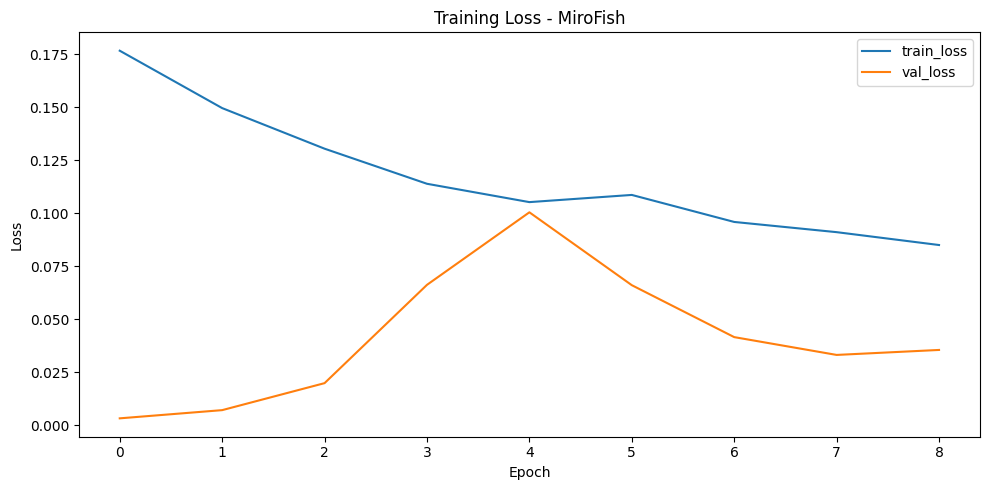

MiroFish salvo em: /Users/karenota/Desktop/Previs-o-de-Criptomoedas---LSTMs/outputs/models/mirofish_model.pt


In [8]:
mirofish_model = MiroFishModel(input_size=X_train.shape[2])

mirofish_model, mirofish_history, mirofish_model_path = train_mirofish_model(
    mirofish_model,
    X_train,
    y_train,
    X_val,
    y_val,
    epochs=20,
    lr=0.005,
    patience=8,
    model_name="mirofish_model.pt",
)

print("MiroFish salvo em:", mirofish_model_path)


## 8. Avaliação do MiroFish


In [9]:
metrics_mirofish, y_true_mirofish, y_pred_mirofish = evaluate_mirofish_model(
    mirofish_model,
    X_test,
    y_test,
    scaler,
)

metrics_mirofish


{'MSE': 12136.162613676708,
 'RMSE': 110.16425288484785,
 'MAE': 104.66574505281511,
 'R2': -5.936787561989084}

## 9. Comparação de métricas


In [10]:
print("LSTM")
print(metrics_lstm)

print("\nMiroFish")
print(metrics_mirofish)


LSTM
{'MSE': 196.5804108723131, 'RMSE': 14.020713636342235, 'MAE': 11.373460066514406, 'R2': 0.887638573041776}

MiroFish
{'MSE': 12136.162613676708, 'RMSE': 110.16425288484785, 'MAE': 104.66574505281511, 'R2': -5.936787561989084}


## 10. Gráfico comparativo


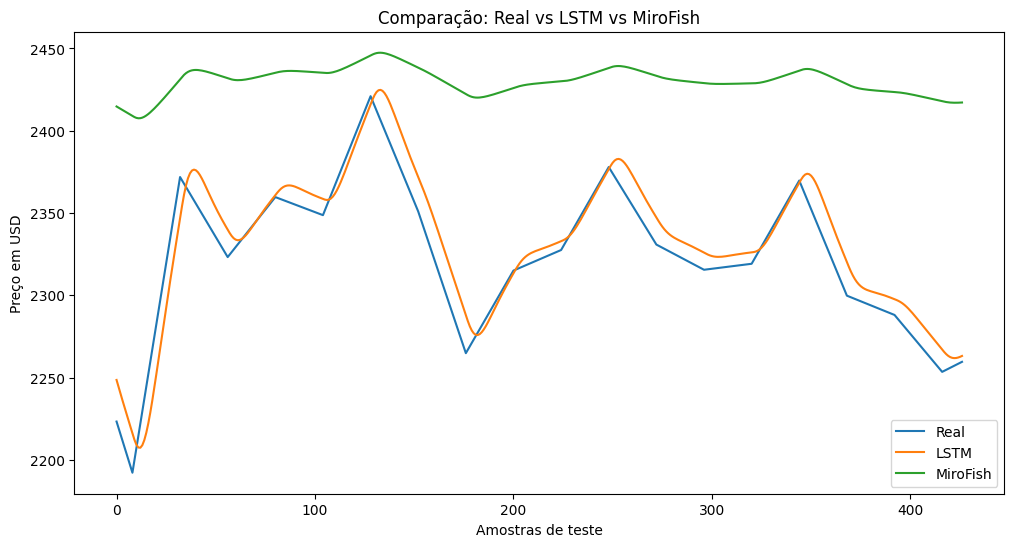

In [11]:
plt.figure(figsize=(12, 6))
plt.plot(y_true_lstm.flatten(), label="Real")
plt.plot(y_pred_lstm.flatten(), label="LSTM")
plt.plot(y_pred_mirofish.flatten(), label="MiroFish")
plt.title("Comparação: Real vs LSTM vs MiroFish")
plt.xlabel("Amostras de teste")
plt.ylabel("Preço em USD")
plt.legend()
plt.show()


## 11. Predição futura com LSTM


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step


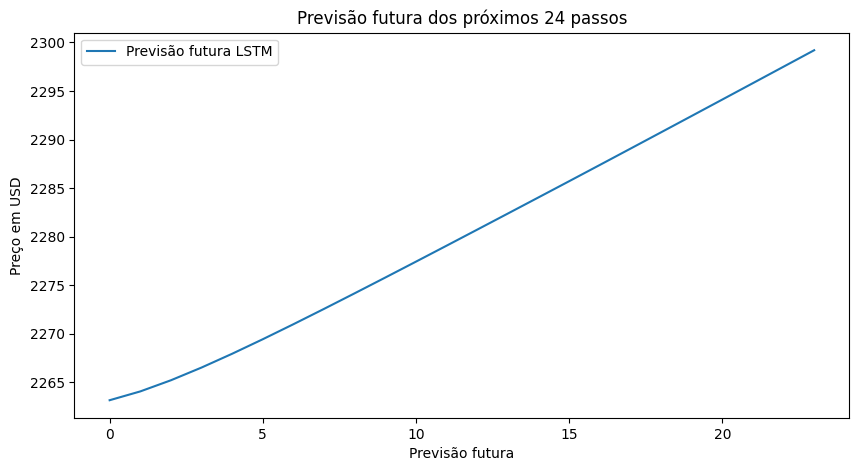

In [12]:
future_lstm = predict_future(
    lstm_model,
    X_test[-1],
    scaler,
    steps=24,
)

plt.figure(figsize=(10, 5))
plt.plot(future_lstm, label="Previsão futura LSTM")
plt.title("Previsão futura dos próximos 24 passos")
plt.xlabel("Previsão futura")
plt.ylabel("Preço em USD")
plt.legend()
plt.show()
